-
-
Step 1: run fastqc on all files (raw data)
-
-
-

In [1]:
#this is just running fastqc on all of the raw data, and putting into results/fastqc_raw

! fastqc /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/clean_1.fastq /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw/clean_1_f
! fastqc /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/clean_2.fastq -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw
! fastqc /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/cow_1.fastq -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw
! fastqc /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/cow_2.fastq -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw
! fastqc /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/gut_1.fastq -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw
! fastqc /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/gut_2.fastq -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw
! fastqc /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/marine_1.fastq -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw
! fastqc /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/marine_2.fastq -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw
! fastqc /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/poll_1.fastq -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw
! fastqc /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/poll_2.fastq -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw



perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
null
Started analysis of clean_2.fastq
Approx 5% complete for clean_2.fastq
Approx 10% complete for clean_2.fastq
Approx 15% complete for clean_2.fastq
Approx 20% complete for clean_2.fastq
Approx 25% complete for clean_2.fastq
Approx 30% complete for clean_2.fastq
Approx 35% complete for clean_2.fastq
Approx 40% complete for clean_2.fastq
Approx 45% complete for clean_2.fastq
Approx 50% complete for clean_2.fastq
Approx 55% complete for clean_2.fastq
Approx 60% complete for clean_2.fastq
Approx 65% complete for clean_2.fastq
Approx 70% complete for clean_2.fastq
Approx 75% complete for clean_2.fastq
Approx 80% complete for clean_2.fastq
Approx 85% complete for clean_2.fastq
Approx 90% complete for clean_2.

-
-
Step 2: Running multiqc on the raw fastqc files 
-
-
-

In [3]:
! multiqc /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw


/// ]8;id=850746;https://multiqc.info\MultiQC]8;;\ 🔍 v1.33

       file_search | Search path: /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc_raw
         searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 21/21  lm  
            fastqc | Found 10 reports
     write_results | Data        : results/fastqc_raw/multiqc_data
     write_results | Report      : results/fastqc_raw/multiqc_report.html
           multiqc | MultiQC complete


-
-
-
Step 3: trim and filter using all tools
-
-
-

Parameters: 
trim tail until quality score 30
filter to mean quality 30
minimum read length 50 nts
adapter trimming

Parameter equivalence table (chatgpt)

| Tool            | Adapter trimming                                        | Trimming (3′/5′ ends)             | Quality filter (mean read quality) | Minimum read length    | Notes                                                                                           |
| --------------- | ------------------------------------------------------- | --------------------------------- | ---------------------------------- | ---------------------- | ----------------------------------------------------------------------------------------------- |
| **fastp**       | `--detect_adapter_for_pe` or `--adapter_sequence`       | `--trim_tail1 30 --trim_tail2 30` | `--cut_mean_quality 30`            | `--length_required 50` | Adapter trimming + quality trimming in one run; automatic adapter detection for paired-end data |
| **Cutadapt**    | `-a ADAPTER` (R1), `-A ADAPTER` (R2)                    | `-q 30` (end trimming)            | Approximate mean via `-q`          | `-m 50`                | Primarily an adapter trimmer with optional quality trimming                                     |
| **Trimmomatic** | `ILLUMINACLIP:adapters.fa`                              | `TRAILING:30`                     | `AVGQUAL:30`                       | `MINLEN:50`            | Adapter trimming requires adapter FASTA file                                                    |
| **Skewer**      | `-x ADAPTER`                                            | `-q 30`                           | Approximate mean                   | `-l 50`                | Designed for adapter trimming plus quality filtering                                            |
| **Prinseq++**   | Not automatic (adapter removal usually done beforehand) | `--trim_qual_right 30`            | `--min_qual_mean 30`               | `--min_len 50`         | Often used for quality filtering after adapter trimming                                         |


In [ ]:
#write code here for the different tools
#we are filtering and trimming at once

################ OBS!!! this does not include measuring the time and resources the computation takes #####
#that is another notebook

In [1]:
%%bash
# specifies the directories that the data is in and where the results will end up
INPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data"
OUTPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastp_results"

# Loop over all R1 files
for fq1 in $INPUT_DIR/*_1.fastq; do
    # Determine paired R2 file
    fq2=${fq1/_1.fastq/_2.fastq}

    # Extract sample name
    sample=$(basename $fq1 | sed 's/_1.fastq//')

    echo "Processing sample $sample ..."

    fastp \
        -i $fq1 -I $fq2 \
        -o $OUTPUT_DIR/${sample}_1_fastp.fastq \
        -O $OUTPUT_DIR/${sample}_2_fastp.fastq \
        --detect_adapter_for_pe \
        --cut_tail \
        --cut_tail_mean_quality 30 \
        --average_qual 30 \
        --length_required 50 \
done

Processing sample airways ...


Detecting adapter sequence for read1...
>Illumina Paired End Adapter 2
GATCGGAAGAGCGGTTCAGCAGGAATGCCGAG

Detecting adapter sequence for read2...
No adapter detected for read2

Read1 before filtering:
total reads: 1500000
total bases: 150000000
Q20 bases: 145108108(96.7387%)
Q30 bases: 139513340(93.0089%)
Q40 bases: 60352294(40.2349%)

Read2 before filtering:
total reads: 1500000
total bases: 150000000
Q20 bases: 142254533(94.8364%)
Q30 bases: 135936013(90.624%)
Q40 bases: 58461321(38.9742%)

Read1 after filtering:
total reads: 2256
total bases: 217257
Q20 bases: 216192(99.5098%)
Q30 bases: 210076(96.6947%)
Q40 bases: 92438(42.5478%)

Read2 after filtering:
total reads: 2256
total bases: 214737
Q20 bases: 213497(99.4225%)
Q30 bases: 207160(96.4715%)
Q40 bases: 92151(42.9134%)

Filtering result:
reads passed filter: 4512
reads failed due to low quality: 4266
reads failed due to too many N: 2
reads failed due to too short: 2988790
reads failed due to adapter dimer: 2430
reads with adapter

Processing sample clean ...


Detecting adapter sequence for read1...
>Nextera_LMP_Read1_External_Adapter | >Illumina Multiplexing Index Sequencing Primer
GATCGGAAGAGCACACGTCTGAACTCCAGTCAC

Detecting adapter sequence for read2...
>Nextera_LMP_Read2_External_Adapter
GATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT

Read1 before filtering:
total reads: 1500000
total bases: 151500000
Q20 bases: 142048780(93.7616%)
Q30 bases: 130675303(86.2543%)
Q40 bases: 36761182(24.2648%)

Read2 before filtering:
total reads: 1500000
total bases: 151500000
Q20 bases: 133370318(88.0332%)
Q30 bases: 121894612(80.4585%)
Q40 bases: 33424719(22.0625%)

Read1 after filtering:
total reads: 1240127
total bases: 120355206
Q20 bases: 119250572(99.0822%)
Q30 bases: 113161280(94.0228%)
Q40 bases: 34656030(28.7948%)

Read2 after filtering:
total reads: 1240127
total bases: 118245313
Q20 bases: 116946874(98.9019%)
Q30 bases: 110531651(93.4766%)
Q40 bases: 32612830(27.5807%)

Filtering result:
reads passed filter: 2480254
reads failed due to low quality: 384368
r

Processing sample cow ...


...

Detecting adapter sequence for read1...
>TruSeq2_PE_r
AGATCGGAAGAGCGGTTCAGCAGGAATGCCGAG

Detecting adapter sequence for read2...
>Illumina TruSeq Adapter Read 2
AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT

Read1 before filtering:
total reads: 1500000
total bases: 142500000
Q20 bases: 138081519(96.8993%)
Q30 bases: 132390216(92.9054%)
Q40 bases: 58866775(41.31%)

Read2 before filtering:
total reads: 1500000
total bases: 142493903
Q20 bases: 135175415(94.864%)
Q30 bases: 125265963(87.9097%)
Q40 bases: 52407510(36.7788%)

Read1 after filtering:
total reads: 1392248
total bases: 129702482
Q20 bases: 128959508(99.4272%)
Q30 bases: 125647459(96.8736%)
Q40 bases: 58057035(44.7617%)

Read2 after filtering:
total reads: 1392248
total bases: 126476253
Q20 bases: 124444428(98.3935%)
Q30 bases: 117574669(92.9619%)
Q40 bases: 51004283(40.3272%)

Filtering result:
reads passed filter: 2784496
reads failed due to low quality: 148976
reads failed due to too many N: 130
reads failed due to too short: 58192
reads

Processing sample marine ...


Detecting adapter sequence for read1...
>Illumina TruSeq Adapter Read 1
AGATCGGAAGAGCACACGTCTGAACTCCAGTCA

Detecting adapter sequence for read2...
>Illumina TruSeq Adapter Read 2
AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT

Read1 before filtering:
total reads: 1500000
total bases: 225000000
Q20 bases: 221826917(98.5897%)
Q30 bases: 216428730(96.1905%)
Q40 bases: 46028745(20.4572%)

Read2 before filtering:
total reads: 1500000
total bases: 225000000
Q20 bases: 216720539(96.3202%)
Q30 bases: 208829489(92.8131%)
Q40 bases: 44773921(19.8995%)

Read1 after filtering:
total reads: 1407004
total bases: 202280174
Q20 bases: 201902660(99.8134%)
Q30 bases: 198888761(98.3234%)
Q40 bases: 44607210(22.0522%)

Read2 after filtering:
total reads: 1407004
total bases: 200677947
Q20 bases: 200018929(99.6716%)
Q30 bases: 195197634(97.2691%)
Q40 bases: 43887580(21.8697%)

Filtering result:
reads passed filter: 2814008
reads failed due to low quality: 132442
reads failed due to too many N: 4730
reads failed due to 

Processing sample poll ...


Detecting adapter sequence for read1...
No adapter detected for read1

Detecting adapter sequence for read2...
No adapter detected for read2

Read1 before filtering:
total reads: 1500000
total bases: 151500000
Q20 bases: 144840043(95.604%)
Q30 bases: 135807085(89.6416%)
Q40 bases: 38853370(25.6458%)

Read2 before filtering:
total reads: 1500000
total bases: 151500000
Q20 bases: 137070524(90.4756%)
Q30 bases: 127088811(83.887%)
Q40 bases: 35425824(23.3834%)

Read1 after filtering:
total reads: 1269983
total bases: 124764516
Q20 bases: 124066775(99.4408%)
Q30 bases: 119571977(95.8381%)
Q40 bases: 36732355(29.4413%)

Read2 after filtering:
total reads: 1269983
total bases: 122922754
Q20 bases: 121945122(99.2047%)
Q30 bases: 116557480(94.8217%)
Q40 bases: 34404213(27.9885%)

Filtering result:
reads passed filter: 2539966
reads failed due to low quality: 349660
reads failed due to too many N: 76
reads failed due to too short: 110014
reads failed due to adapter dimer: 284
reads with adapter 

In [5]:
%%bash
############### Cutadapt ####################

# specifies the directories that the data is in and where the results will end up
INPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data"
OUTPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/cutadapt_results"

# Loop over all R1 files
for fq1 in $INPUT_DIR/*_1.fastq; do
    # Determine paired R2 file
    fq2=${fq1/_1.fastq/_2.fastq}

    # Extract sample name
    sample=$(basename $fq1 | sed 's/_1.fastq//')

     # Assign adapters for each sample individually
    if [ "$sample" == "airways" ]; then
        r1_adapter="GATCGGAAGAGCGGTTCAGCAGGAATGCCGAG"
        r2_adapter=""
    elif [ "$sample" == "clean" ]; then
        r1_adapter="GATCGGAAGAGCACACGTCTGAACTCCAGTCAC"
        r2_adapter="GATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT"
    elif [ "$sample" == "gut" ]; then
        r1_adapter="AGATCGGAAGAGCGGTTCAGCAGGAATGCCGAG"
        r2_adapter="AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT"
    elif [ "$sample" == "marine" ]; then
        r1_adapter="AGATCGGAAGAGCACACGTCTGAACTCCAGTCA"
        r2_adapter="AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT"
    else
        # Samples without adapters
        r1_adapter=""
        r2_adapter=""
    fi
   
    # Run cutadapt
    if [ -n "$r1_adapter" ] && [ -n "$r2_adapter" ]; then
        cutadapt \
            -a $r1_adapter -A $r2_adapter \
            -q 30 -m 50 \
            -o "$OUTPUT_DIR/${sample}_1_cutadapt.fastq" \
            -p "$OUTPUT_DIR/${sample}_2_cutadapt.fastq" \
            $fq1 $fq2
    elif [ -n "$r1_adapter" ]; then
        cutadapt \
            -a $r1_adapter \
            -q 30 -m 50 \
            -o "$OUTPUT_DIR/${sample}_1_cutadapt.fastq" \
            -p "$OUTPUT_DIR/${sample}_2_cutadapt.fastq" \
            $fq1 $fq2
            
    else
        # Only tail trimming + min length
        cutadapt \
            -q 30 -m 50 \
            -o "$OUTPUT_DIR/${sample}_1_cutadapt.fastq" \
            -p "$OUTPUT_DIR/${sample}_2_cutadapt.fastq" \
            $fq1 $fq2
    fi


done


This is cutadapt 5.2 with Python 3.12.12
Command line parameters: -a GATCGGAAGAGCGGTTCAGCAGGAATGCCGAG -q 30 -m 50 -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/cutadapt_results/airways_1_cutadapt.fastq -p /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/cutadapt_results/airways_2_cutadapt.fastq /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/airways_1.fastq /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/airways_2.fastq
Processing paired-end reads on 1 core ...

=== Summary ===

Total read pairs processed:          1,500,000
  Read 1 with adapter:                   3,742 (0.2%)

== Read fate breakdown ==
Pairs that were too short:             123,316 (8.2%)
Pairs written (passing filters):     1,376,684 (91.8%)

Total basepairs processed:   300,000,000 bp
  Read 1:   150,000,000 bp
  Read 2:   150,000,000 bp
Quality-trimmed:              19,782,081 bp (6.6%)
  Read 1:     7,899,394 bp
  Read 2:    11,882,687 bp
Total written (

In [9]:
%%bash
############### Trimmomatic (paired reads only) ####################

# Directories
INPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data"
OUTPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results"
ADAPTER_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/adapters"

# Loop over samples
for sample in airways clean gut cow marine poll; do
    fq1="$INPUT_DIR/${sample}_1.fastq"
    fq2="$INPUT_DIR/${sample}_2.fastq"

    echo "Processing $sample ..."

    # Assign adapter file for samples that have adapters
    case "$sample" in
        airways)
            adapter_file="$ADAPTER_DIR/adapters_airways.fa"
            ;;
        clean)
            adapter_file="$ADAPTER_DIR/adapters_clean.fa"
            ;;
        gut)
            adapter_file="$ADAPTER_DIR/adapters_gut.fa"
            ;;
        marine)
            adapter_file="$ADAPTER_DIR/adapters_marine.fa"
            ;;
        *)
            adapter_file=""
            ;;
    esac

    # Set output filenames (paired reads only, include trimmomatic in name)
    R1_paired="$OUTPUT_DIR/${sample}_1_trimmomatic.fastq"
    R2_paired="$OUTPUT_DIR/${sample}_2_trimmomatic.fastq"

    # Run Trimmomatic
    if [ -n "$adapter_file" ]; then
        java -jar /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/trimmomatic-0.39.jar PE \
            -threads 4 \
            $fq1 $fq2 \
            $R1_paired /dev/null \
            $R2_paired /dev/null \
            ILLUMINACLIP:$adapter_file:2:30:10 \
            TRAILING:30 \
            MINLEN:50 \
            AVGQUAL:30
    else
        java -jar /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/trimmomatic-0.39.jar PE \
            -threads 4 \
            $fq1 $fq2 \
            $R1_paired /dev/null \
            $R2_paired /dev/null \
            TRAILING:30 \
            MINLEN:50 \
            AVGQUAL:30
    fi
done


Processing airways ...


TrimmomaticPE: Started with arguments:
 -threads 4 /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/airways_1.fastq /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/airways_2.fastq /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/airways_1_trimmomatic.fastq /dev/null /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/airways_2_trimmomatic.fastq /dev/null ILLUMINACLIP:/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/adapters/adapters_airways.fa:2:30:10 TRAILING:30 MINLEN:50 AVGQUAL:30
Using Long Clipping Sequence: 'GATCGGAAGAGCGGTTCAGCAGGAATGCCGAG'
ILLUMINACLIP: Using 0 prefix pairs, 1 forward/reverse sequences, 0 forward only sequences, 0 reverse only sequences
Quality encoding detected as phred33
Input Read Pairs: 1500000 Both Surviving: 2283 (0.15%) Forward Only Surviving: 168 (0.01%) Reverse Only Surviving: 766 (0.05%) Dropped: 1496783 (99.79%)
TrimmomaticPE: Completed successfully


Processing clean ...


TrimmomaticPE: Started with arguments:
 -threads 4 /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/clean_1.fastq /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/clean_2.fastq /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/clean_1_trimmomatic.fastq /dev/null /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/clean_2_trimmomatic.fastq /dev/null ILLUMINACLIP:/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/adapters/adapters_clean.fa:2:30:10 TRAILING:30 MINLEN:50 AVGQUAL:30
Using Long Clipping Sequence: 'GATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT'
Using Long Clipping Sequence: 'GATCGGAAGAGCACACGTCTGAACTCCAGTCAC'
ILLUMINACLIP: Using 0 prefix pairs, 2 forward/reverse sequences, 0 forward only sequences, 0 reverse only sequences
Quality encoding detected as phred33
Input Read Pairs: 1500000 Both Surviving: 1232333 (82.16%) Forward Only Surviving: 128479 (8.57%) Reverse Only Surviving: 33730 (2.25%) Dro

Processing gut ...


...

TrimmomaticPE: Started with arguments:
 -threads 4 /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/cow_1.fastq /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/cow_2.fastq /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/cow_1_trimmomatic.fastq /dev/null /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/cow_2_trimmomatic.fastq /dev/null TRAILING:30 MINLEN:50 AVGQUAL:30
Quality encoding detected as phred33
Input Read Pairs: 1500000 Both Surviving: 1152209 (76.81%) Forward Only Surviving: 270472 (18.03%) Reverse Only Surviving: 19186 (1.28%) Dropped: 58133 (3.88%)
TrimmomaticPE: Completed successfully


Processing marine ...


TrimmomaticPE: Started with arguments:
 -threads 4 /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/marine_1.fastq /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/marine_2.fastq /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/marine_1_trimmomatic.fastq /dev/null /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/marine_2_trimmomatic.fastq /dev/null ILLUMINACLIP:/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/adapters/adapters_marine.fa:2:30:10 TRAILING:30 MINLEN:50 AVGQUAL:30
Using Long Clipping Sequence: 'AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT'
Using Long Clipping Sequence: 'AGATCGGAAGAGCACACGTCTGAACTCCAGTCA'
ILLUMINACLIP: Using 0 prefix pairs, 2 forward/reverse sequences, 0 forward only sequences, 0 reverse only sequences
Quality encoding detected as phred33
Input Read Pairs: 1500000 Both Surviving: 1410302 (94.02%) Forward Only Surviving: 54769 (3.65%) Reverse Only Surviving: 19918 (1.33%

Processing poll ...


TrimmomaticPE: Started with arguments:
 -threads 4 /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/poll_1.fastq /cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data/poll_2.fastq /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/poll_1_trimmomatic.fastq /dev/null /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/poll_2_trimmomatic.fastq /dev/null TRAILING:30 MINLEN:50 AVGQUAL:30
Quality encoding detected as phred33
Input Read Pairs: 1500000 Both Surviving: 1270445 (84.70%) Forward Only Surviving: 131768 (8.78%) Reverse Only Surviving: 34633 (2.31%) Dropped: 63154 (4.21%)
TrimmomaticPE: Completed successfully


In [1]:
%%bash
############### Skewer ####################

INPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Project_Data/Teaching_Data"
OUTPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/skewer_results"

# Loop over R1 files
for fq1 in $INPUT_DIR/*_1.fastq; do

    fq2=${fq1/_1.fastq/_2.fastq}

    sample=$(basename $fq1 | sed 's/_1.fastq//')

    # Assign adapters per sample
    if [ "$sample" == "airways" ]; then
        r1_adapter="GATCGGAAGAGCGGTTCAGCAGGAATGCCGAG"
        r2_adapter=""
    elif [ "$sample" == "clean" ]; then
        r1_adapter="GATCGGAAGAGCACACGTCTGAACTCCAGTCAC"
        r2_adapter="GATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT"
    elif [ "$sample" == "gut" ]; then
        r1_adapter="AGATCGGAAGAGCGGTTCAGCAGGAATGCCGAG"
        r2_adapter="AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT"
    elif [ "$sample" == "marine" ]; then
        r1_adapter="AGATCGGAAGAGCACACGTCTGAACTCCAGTCA"
        r2_adapter="AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT"
    else
        r1_adapter=""
        r2_adapter=""
    fi


    if [ -n "$r1_adapter" ] && [ -n "$r2_adapter" ]; then

        skewer \
            -x $r1_adapter \
            -y $r2_adapter \
            -q 30 \
            -l 50 \
            -m pe \
            -o "$OUTPUT_DIR/${sample}_skewer" \
            $fq1 $fq2

    elif [ -n "$r1_adapter" ]; then

        skewer \
            -x $r1_adapter \
            -q 30 \
            -l 50 \
            -m pe \
            -o "$OUTPUT_DIR/${sample}_skewer" \
            $fq1 $fq2

    else

        skewer \
            -q 30 \
            -l 50 \
            -m pe \
            -o "$OUTPUT_DIR/${sample}_skewer" \
            $fq1 $fq2

    fi

done



|=================================================>| (100.00%)

.--. .-.
: .--': :.-.
`. `. : `'.' .--. .-..-..-. .--. .--.
_`, :: . `.' '_.': `; `; :' '_.': ..'
`.__.':_;:_;`.__.'`.__.__.'`.__.':_;
skewer v0.2.2 [April 4, 2016]
Parameters used:
-- 3' end adapter sequence (-x):	GATCGGAAGAGCGGTTCAGCAGGAATGCCGAG
-- maximum error ratio allowed (-r):	0.100
-- maximum indel error ratio allowed (-d):	0.030
-- end quality threshold (-q):		30
-- minimum read length allowed after trimming (-l):	50
-- file format (-f):		Sanger/Illumina 1.8+ FASTQ (auto detected)
Fri Mar  6 13:28:06 2026 >> started

Fri Mar  6 13:28:19 2026 >> done (12.770s)
1500000 read pairs processed; of these:
  39875 ( 2.66%) short read pairs filtered out after trimming by size control
   5722 ( 0.38%) empty read pairs filtered out after trimming by size control
1454403 (96.96%) read pairs available; of these:
 508730 (34.98%) trimmed read pairs available after processing
 945673 (65.02%) untrimmed read pairs available after processing
log has been saved to "/cephyr/NOBACKUP/courses/BBT0

|=================================================>| (100.00%)

.--. .-.
: .--': :.-.
`. `. : `'.' .--. .-..-..-. .--. .--.
_`, :: . `.' '_.': `; `; :' '_.': ..'
`.__.':_;:_;`.__.'`.__.__.'`.__.':_;
skewer v0.2.2 [April 4, 2016]
Parameters used:
-- 3' end adapter sequence (-x):	GATCGGAAGAGCACACGTCTGAACTCCAGTCAC
-- paired 3' end adapter sequence (-y):	GATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT
-- maximum error ratio allowed (-r):	0.100
-- maximum indel error ratio allowed (-d):	0.030
-- end quality threshold (-q):		30
-- minimum read length allowed after trimming (-l):	50
-- file format (-f):		Sanger/Illumina 1.8+ FASTQ (auto detected)
Fri Mar  6 13:28:19 2026 >> started

Fri Mar  6 13:28:39 2026 >> done (19.808s)
1500000 read pairs processed; of these:
  74959 ( 5.00%) short read pairs filtered out after trimming by size control
  31814 ( 2.12%) empty read pairs filtered out after trimming by size control
1393227 (92.88%) read pairs available; of these:
1192287 (85.58%) trimmed read pairs available after processing
 200940 (14.42%) untrimmed read pairs avail

|=================================================>| (100.00%)

...

.--. .-.
: .--': :.-.
`. `. : `'.' .--. .-..-..-. .--. .--.
_`, :: . `.' '_.': `; `; :' '_.': ..'
`.__.':_;:_;`.__.'`.__.__.'`.__.':_;
skewer v0.2.2 [April 4, 2016]
Parameters used:
-- 3' end adapter sequence (-x):	AGATCGGAAGAGCGGTTCAGCAGGAATGCCGAG
-- paired 3' end adapter sequence (-y):	AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT
-- maximum error ratio allowed (-r):	0.100
-- maximum indel error ratio allowed (-d):	0.030
-- end quality threshold (-q):		30
-- minimum read length allowed after trimming (-l):	50
-- file format (-f):		Sanger/Illumina 1.8+ FASTQ (auto detected)
Fri Mar  6 13:29:06 2026 >> started

Fri Mar  6 13:29:23 2026 >> done (16.878s)
1500000 read pairs processed; of these:
  30626 ( 2.04%) short read pairs filtered out after trimming by size control
   2359 ( 0.16%) empty read pairs filtered out after trimming by size control
1467015 (97.80%) read pairs available; of these:
 657861 (44.84%) trimmed read pairs available after processing
 809154 (55.16%) untrimmed read pairs avai

|=================================================>| (100.00%)

.--. .-.
: .--': :.-.
`. `. : `'.' .--. .-..-..-. .--. .--.
_`, :: . `.' '_.': `; `; :' '_.': ..'
`.__.':_;:_;`.__.'`.__.__.'`.__.':_;
skewer v0.2.2 [April 4, 2016]
Parameters used:
-- 3' end adapter sequence (-x):	AGATCGGAAGAGCACACGTCTGAACTCCAGTCA
-- paired 3' end adapter sequence (-y):	AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT
-- maximum error ratio allowed (-r):	0.100
-- maximum indel error ratio allowed (-d):	0.030
-- end quality threshold (-q):		30
-- minimum read length allowed after trimming (-l):	50
-- file format (-f):		Sanger/Illumina 1.8+ FASTQ (auto detected)
Fri Mar  6 13:29:23 2026 >> started

Fri Mar  6 13:29:47 2026 >> done (24.080s)
1500000 read pairs processed; of these:
  22715 ( 1.51%) short read pairs filtered out after trimming by size control
   6169 ( 0.41%) empty read pairs filtered out after trimming by size control
1471116 (98.07%) read pairs available; of these:
 456779 (31.05%) trimmed read pairs available after processing
1014337 (68.95%) untrimmed read pairs avai

|=================================================>| (100.00%)

.--. .-.
: .--': :.-.
`. `. : `'.' .--. .-..-..-. .--. .--.
_`, :: . `.' '_.': `; `; :' '_.': ..'
`.__.':_;:_;`.__.'`.__.__.'`.__.':_;
skewer v0.2.2 [April 4, 2016]
Parameters used:
-- 3' end adapter sequence (-x):	AGATCGGAAGAGCACACGTCTGAACTCCAGTCAC
-- paired 3' end adapter sequence (-y):	AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGTA
-- maximum error ratio allowed (-r):	0.100
-- maximum indel error ratio allowed (-d):	0.030
-- end quality threshold (-q):		30
-- minimum read length allowed after trimming (-l):	50
-- file format (-f):		Sanger/Illumina 1.8+ FASTQ (auto detected)
Fri Mar  6 13:29:47 2026 >> started

Fri Mar  6 13:30:06 2026 >> done (19.301s)
1500000 read pairs processed; of these:
  86448 ( 5.76%) short read pairs filtered out after trimming by size control
  15055 ( 1.00%) empty read pairs filtered out after trimming by size control
1398497 (93.23%) read pairs available; of these:
 862869 (61.70%) trimmed read pairs available after processing
 535628 (38.30%) untrimmed read pairs av

In [ ]:
############ Prinseq++ ###########################
# do not use prinseq

-
-
-
-
-
-
Now we want to run fastqc again, after the data has gone through all of the tools
-
-
-
-
-

In [4]:
%%bash
########### fastp ################


INPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastp_results"
OUTPUT_DIR="$INPUT_DIR/fastp_fastqc"

for fq in $INPUT_DIR/*_fastp.fastq; do
    echo "Running FastQC on $(basename $fq)"
    fastqc $fq -o $OUTPUT_DIR
done

Running FastQC on airways_1_fastp.fastq


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").


null


Started analysis of airways_1_fastp.fastq
Approx 45% complete for airways_1_fastp.fastq
Approx 85% complete for airways_1_fastp.fastq


Analysis complete for airways_1_fastp.fastq
Running FastQC on airways_2_fastp.fastq


...

Analysis complete for poll_1_fastp.fastq
Running FastQC on poll_2_fastp.fastq


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").


null


Started analysis of poll_2_fastp.fastq
Approx 5% complete for poll_2_fastp.fastq
Approx 10% complete for poll_2_fastp.fastq
Approx 15% complete for poll_2_fastp.fastq
Approx 20% complete for poll_2_fastp.fastq
Approx 25% complete for poll_2_fastp.fastq
Approx 30% complete for poll_2_fastp.fastq
Approx 35% complete for poll_2_fastp.fastq
Approx 40% complete for poll_2_fastp.fastq
Approx 45% complete for poll_2_fastp.fastq
Approx 50% complete for poll_2_fastp.fastq
Approx 55% complete for poll_2_fastp.fastq
Approx 60% complete for poll_2_fastp.fastq
Approx 65% complete for poll_2_fastp.fastq
Approx 70% complete for poll_2_fastp.fastq
Approx 75% complete for poll_2_fastp.fastq
Approx 80% complete for poll_2_fastp.fastq
Approx 85% complete for poll_2_fastp.fastq
Approx 90% complete for poll_2_fastp.fastq
Approx 95% complete for poll_2_fastp.fastq


Analysis complete for poll_2_fastp.fastq


In [7]:
%%bash
#running fastqc on cutadapt data

INPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/cutadapt_results/"
OUTPUT_DIR="$INPUT_DIR/cutadapt_fastqc"

for fq in $INPUT_DIR/*_cutadapt.fastq; do
    echo "Running FastQC on $(basename $fq)"
    fastqc $fq -o $OUTPUT_DIR
done

Running FastQC on airways_1_cutadapt.fastq


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").


null


Started analysis of airways_1_cutadapt.fastq
Approx 5% complete for airways_1_cutadapt.fastq
Approx 10% complete for airways_1_cutadapt.fastq
Approx 15% complete for airways_1_cutadapt.fastq
Approx 20% complete for airways_1_cutadapt.fastq
Approx 25% complete for airways_1_cutadapt.fastq
Approx 30% complete for airways_1_cutadapt.fastq
Approx 35% complete for airways_1_cutadapt.fastq
Approx 40% complete for airways_1_cutadapt.fastq
Approx 45% complete for airways_1_cutadapt.fastq
Approx 50% complete for airways_1_cutadapt.fastq
Approx 55% complete for airways_1_cutadapt.fastq
Approx 60% complete for airways_1_cutadapt.fastq
Approx 65% complete for airways_1_cutadapt.fastq
Approx 70% complete for airways_1_cutadapt.fastq
Approx 75% complete for airways_1_cutadapt.fastq
Approx 80% complete for airways_1_cutadapt.fastq
Approx 85% complete for airways_1_cutadapt.fastq
Approx 90% complete for airways_1_cutadapt.fastq
Approx 95% complete for airways_1_cutadapt.fastq


Analysis complete for airways_1_cutadapt.fastq
Running FastQC on airways_2_cutadapt.fastq


...

Analysis complete for poll_1_cutadapt.fastq
Running FastQC on poll_2_cutadapt.fastq


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").


null


Started analysis of poll_2_cutadapt.fastq
Approx 5% complete for poll_2_cutadapt.fastq
Approx 10% complete for poll_2_cutadapt.fastq
Approx 15% complete for poll_2_cutadapt.fastq
Approx 20% complete for poll_2_cutadapt.fastq
Approx 25% complete for poll_2_cutadapt.fastq
Approx 30% complete for poll_2_cutadapt.fastq
Approx 35% complete for poll_2_cutadapt.fastq
Approx 40% complete for poll_2_cutadapt.fastq
Approx 45% complete for poll_2_cutadapt.fastq
Approx 50% complete for poll_2_cutadapt.fastq
Approx 55% complete for poll_2_cutadapt.fastq
Approx 60% complete for poll_2_cutadapt.fastq
Approx 65% complete for poll_2_cutadapt.fastq
Approx 70% complete for poll_2_cutadapt.fastq
Approx 75% complete for poll_2_cutadapt.fastq
Approx 80% complete for poll_2_cutadapt.fastq
Approx 85% complete for poll_2_cutadapt.fastq
Approx 90% complete for poll_2_cutadapt.fastq
Approx 95% complete for poll_2_cutadapt.fastq


Analysis complete for poll_2_cutadapt.fastq


In [11]:
%%bash
#running fastqc on trimmomatic data

INPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/"
OUTPUT_DIR="$INPUT_DIR/trimmomatic_fastqc"

for fq in $INPUT_DIR/*_trimmomatic.fastq; do
    echo "Running FastQC on $(basename $fq)"
    fastqc $fq -o $OUTPUT_DIR
done

Running FastQC on airways_1_trimmomatic.fastq


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").


null


Started analysis of airways_1_trimmomatic.fastq
Approx 40% complete for airways_1_trimmomatic.fastq
Approx 85% complete for airways_1_trimmomatic.fastq


Analysis complete for airways_1_trimmomatic.fastq
Running FastQC on airways_2_trimmomatic.fastq


...

Analysis complete for poll_1_trimmomatic.fastq
Running FastQC on poll_2_trimmomatic.fastq


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").


null


Started analysis of poll_2_trimmomatic.fastq
Approx 5% complete for poll_2_trimmomatic.fastq
Approx 10% complete for poll_2_trimmomatic.fastq
Approx 15% complete for poll_2_trimmomatic.fastq
Approx 20% complete for poll_2_trimmomatic.fastq
Approx 25% complete for poll_2_trimmomatic.fastq
Approx 30% complete for poll_2_trimmomatic.fastq
Approx 35% complete for poll_2_trimmomatic.fastq
Approx 40% complete for poll_2_trimmomatic.fastq
Approx 45% complete for poll_2_trimmomatic.fastq
Approx 50% complete for poll_2_trimmomatic.fastq
Approx 55% complete for poll_2_trimmomatic.fastq
Approx 60% complete for poll_2_trimmomatic.fastq
Approx 65% complete for poll_2_trimmomatic.fastq
Approx 70% complete for poll_2_trimmomatic.fastq
Approx 75% complete for poll_2_trimmomatic.fastq
Approx 80% complete for poll_2_trimmomatic.fastq
Approx 85% complete for poll_2_trimmomatic.fastq
Approx 90% complete for poll_2_trimmomatic.fastq
Approx 95% complete for poll_2_trimmomatic.fastq


Analysis complete for poll_2_trimmomatic.fastq


In [5]:
%%bash
########### skewer #############


INPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/skewer_results"
OUTPUT_DIR="$INPUT_DIR/skewer_fastqc"

for fq in $INPUT_DIR/*-pair2.fastq; do #skewer #change to pair1 or pair2, the files got named weird by skewer
    echo "Running FastQC on $(basename $fq)"
    fastqc $fq -o $OUTPUT_DIR
done

Running FastQC on airways_skewer-trimmed-pair2.fastq


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").


null


Started analysis of airways_skewer-trimmed-pair2.fastq
Approx 5% complete for airways_skewer-trimmed-pair2.fastq
Approx 10% complete for airways_skewer-trimmed-pair2.fastq
Approx 15% complete for airways_skewer-trimmed-pair2.fastq
Approx 20% complete for airways_skewer-trimmed-pair2.fastq
Approx 25% complete for airways_skewer-trimmed-pair2.fastq
Approx 30% complete for airways_skewer-trimmed-pair2.fastq
Approx 35% complete for airways_skewer-trimmed-pair2.fastq
Approx 40% complete for airways_skewer-trimmed-pair2.fastq
Approx 45% complete for airways_skewer-trimmed-pair2.fastq
Approx 50% complete for airways_skewer-trimmed-pair2.fastq
Approx 55% complete for airways_skewer-trimmed-pair2.fastq
Approx 60% complete for airways_skewer-trimmed-pair2.fastq
Approx 65% complete for airways_skewer-trimmed-pair2.fastq
Approx 70% complete for airways_skewer-trimmed-pair2.fastq
Approx 75% complete for airways_skewer-trimmed-pair2.fastq
Approx 80% complete for airways_skewer-trimmed-pair2.fastq
Ap

Analysis complete for airways_skewer-trimmed-pair2.fastq
Running FastQC on clean_skewer-trimmed-pair2.fastq


...

Analysis complete for marine_skewer-trimmed-pair2.fastq
Running FastQC on poll_skewer-trimmed-pair2.fastq


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").


null


Started analysis of poll_skewer-trimmed-pair2.fastq
Approx 5% complete for poll_skewer-trimmed-pair2.fastq
Approx 10% complete for poll_skewer-trimmed-pair2.fastq
Approx 15% complete for poll_skewer-trimmed-pair2.fastq
Approx 20% complete for poll_skewer-trimmed-pair2.fastq
Approx 25% complete for poll_skewer-trimmed-pair2.fastq
Approx 30% complete for poll_skewer-trimmed-pair2.fastq
Approx 35% complete for poll_skewer-trimmed-pair2.fastq
Approx 40% complete for poll_skewer-trimmed-pair2.fastq
Approx 45% complete for poll_skewer-trimmed-pair2.fastq
Approx 50% complete for poll_skewer-trimmed-pair2.fastq
Approx 55% complete for poll_skewer-trimmed-pair2.fastq
Approx 60% complete for poll_skewer-trimmed-pair2.fastq
Approx 65% complete for poll_skewer-trimmed-pair2.fastq
Approx 70% complete for poll_skewer-trimmed-pair2.fastq
Approx 75% complete for poll_skewer-trimmed-pair2.fastq
Approx 80% complete for poll_skewer-trimmed-pair2.fastq
Approx 85% complete for poll_skewer-trimmed-pair2.fas

Analysis complete for poll_skewer-trimmed-pair2.fastq


In [7]:
%%bash
# multiqc for all tools

multiqc /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/cutadapt_results/cutadapt_fastqc -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/multiqc

multiqc /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastp_results/fastp_fastqc -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/multiqc

multiqc /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/skewer_results/skewer_fastqc -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/multiqc

multiqc /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/trimmomatic_fastqc -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/multiqc


/// ]8;id=355653;https://multiqc.info\MultiQC]8;;\ 🔍 v1.33

       file_search | Search path: /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/cutadapt_results/cutadapt_fastqc
         searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 20/20  lm  
            fastqc | Found 10 reports
     write_results | Data        : results/multiqc/multiqc_data
     write_results | Report      : results/multiqc/multiqc_report.html
           multiqc | MultiQC complete

/// ]8;id=419055;https://multiqc.info\MultiQC]8;;\ 🔍 v1.33

       file_search | Search path: /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastp_results/fastp_fastqc
         searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 20/20  lm  
            fastqc | Found 10 reports
     write_results | Existing reports found, adding suffix to filenames. Use '--force' to overwrite.
     write_results | Data        : results/multiqc/multiqc_data_1
     write_results | Report      : res

In [3]:
%%bash
######### multiqc
 multiqc /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc -o /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/multiqc/combined


/// ]8;id=903654;https://multiqc.info\MultiQC]8;;\ 🔍 v1.33

       file_search | Search path: /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastqc
         searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 104/104  0m  
            fastqc | Found 50 reports
     write_results | Existing reports found, adding suffix to filenames. Use '--force' to overwrite.
     write_results | Data        : results/multiqc/combined/multiqc_data_1
     write_results | Report      : results/multiqc/combined/multiqc_report_1.html
           multiqc | MultiQC complete


-
-
-
Now to run metaphlan on all of the data
-
-
-


In [2]:
%%bash

#fastp 

INPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/fastp_results"
OUTPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/metaphlan/fastp_metaphlan/"

for fq1 in $INPUT_DIR/*_1*.fastq; do

    fq2=${fq1/_1/_2}

    sample=$(basename $fq1 | sed 's/_1.*.fastq//')

    echo "Running MetaPhlAn on $sample"

    metaphlan \
    $fq1,$fq2 \
    --input_type fastq \
    --nproc 4 \
    --bowtie2out "$OUTPUT_DIR/${sample}.bowtie2.bz2" \
    -o "$OUTPUT_DIR/${sample}_metaphlan_profile.txt"

done

Running MetaPhlAn on airways


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


Running MetaPhlAn on clean


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


Running MetaPhlAn on cow


...

perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
An additional column listing the merged species is added to the MetaPhlAn output.


Running MetaPhlAn on marine


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


Running MetaPhlAn on poll


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
An additional column listing the merged species is added to the MetaPhlAn output.


In [1]:
%%bash

#cutadapt

INPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/cutadapt_results/"
OUTPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/metaphlan/cutadapt_metaphlan/"

for fq1 in $INPUT_DIR/*_1*.fastq; do

    fq2=${fq1/_1/_2}

    sample=$(basename $fq1 | sed 's/_1.*.fastq//')

    echo "Running MetaPhlAn on $sample"

    metaphlan \
    $fq1,$fq2 \
    --input_type fastq \
    --nproc 4 \
    --bowtie2out "$OUTPUT_DIR/${sample}.bowtie2.bz2" \
    -o "$OUTPUT_DIR/${sample}_metaphlan_profile.txt"

done

Running MetaPhlAn on airways


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


Running MetaPhlAn on clean


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


Running MetaPhlAn on cow


...

perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
An additional column listing the merged species is added to the MetaPhlAn output.


Running MetaPhlAn on marine


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


Running MetaPhlAn on poll


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
An additional column listing the merged species is added to the MetaPhlAn output.


In [5]:
%%bash

#trimmomatic

INPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/trimmomatic_results/"
OUTPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/metaphlan/trimmomatic_metaphlan/"

for fq1 in $INPUT_DIR/*_1*.fastq; do

    fq2=${fq1/_1/_2}

    sample=$(basename $fq1 | sed 's/_1.*.fastq//')

    echo "Running MetaPhlAn on $sample"

    metaphlan \
    $fq1,$fq2 \
    --input_type fastq \
    --nproc 4 \
    --bowtie2out "$OUTPUT_DIR/${sample}.bowtie2.bz2" \
    -o "$OUTPUT_DIR/${sample}_metaphlan_profile.txt"

done

Running MetaPhlAn on airways


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


Running MetaPhlAn on clean


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


Running MetaPhlAn on cow


...

perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
An additional column listing the merged species is added to the MetaPhlAn output.


Running MetaPhlAn on marine


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


Running MetaPhlAn on poll


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
An additional column listing the merged species is added to the MetaPhlAn output.


In [ ]:
%%bash

# Skewer

INPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/skewer_results/"
OUTPUT_DIR="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/metaphlan/skewer_metaphlan/"

for fq1 in $INPUT_DIR/*1*.fastq; do

    # Replace the trailing 1.fastq with 2.fastq for the mate
    fq2=${fq1/1.fastq/2.fastq}

    # Extract the sample name (remove the trailing 1 or 2 and extension)
    sample=$(basename $fq1 | sed 's/1.fastq//')

    echo "Running MetaPhlAn on $sample"

    metaphlan \
    $fq1,$fq2 \
    --input_type fastq \
    --nproc 4 \
    --bowtie2out "$OUTPUT_DIR/${sample}.bowtie2.bz2" \
    -o "$OUTPUT_DIR/${sample}_metaphlan_profile.txt"

done

Running MetaPhlAn on airways_skewer-trimmed-pair


perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


In [1]:
#compiling metaphlan results from fastp and merge together,
#while deleting airways since everything is unclassified

! merge_metaphlan_tables.py /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/metaphlan/fastp_metaphlan/*_metaphlan_profile.txt \
> merged_fastp_abundance_table.txt

# same for trimmomatic: 
! merge_metaphlan_tables.py /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/metaphlan/trimmomatic_metaphlan/*_metaphlan_profile.txt \
> merged_trimmomatic_abundance_table.txt

#cutadpt:
! merge_metaphlan_tables.py /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/metaphlan/cutadapt_metaphlan/*_metaphlan_profile.txt \
> merged_cutadapt_abundance_table.txt

#skewer:

! merge_metaphlan_tables.py /cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/metaphlan/skewer_metaphlan/*_metaphlan_profile.txt \
> merged_skewer_abundance_table.txt

-
-
-
making top 10 plots
-
-
-

In [38]:
import pandas as pd


########################################## fastp ####################################################
# Load MetaPhlAn merged table
df = pd.read_csv(
    "merged_fastp_abundance_table.txt",
    sep="\t",
    comment="#",  # skip MetaPhlAn header line
)

# Rename abundance columns for convenience
df.rename(columns={
    "clade_name": "Taxonomy",
    "clean_metaphlan": "clean",
    "gut_metaphlan": "gut",
    "marine_metaphlan": "marine"
}, inplace=True)

# Keep only numeric columns + Taxonomy
samples = ["clean", "gut", "marine"]
df[samples] = df[samples].apply(pd.to_numeric, errors='coerce').fillna(0)

# Keep only rows that have a species (contain s__)
df_species = df[df['Taxonomy'].str.contains(r'\|s__')].copy()

# Split taxonomy into parts
tax_split = df_species['Taxonomy'].str.split('|', expand=True)

# Extract Phylum (p__) and Species (s__)
df_species['Phylum'] = tax_split.apply(lambda x: next((v.replace('p__','') for v in x if v.startswith('p__')), 'Unknown'), axis=1)
df_species['Species'] = tax_split.apply(lambda x: next((v.replace('s__','') for v in x if v.startswith('s__')), 'Unknown'), axis=1)

# Keep only the relevant columns
df_species = df_species[['Phylum', 'Species'] + samples]

# Save species abundance table
df_species.to_csv("species_fastp_abundance_table.txt", sep="\t", index=False)

################################################## cutadapt ################################
# Load MetaPhlAn merged table
df = pd.read_csv(
    "merged_cutadapt_abundance_table.txt",
    sep="\t",
    comment="#",  # skip MetaPhlAn header line
)

# Rename abundance columns for convenience
df.rename(columns={
    "clade_name": "Taxonomy",
    "clean_metaphlan": "clean",
    "gut_metaphlan": "gut",
    "marine_metaphlan": "marine"
}, inplace=True)

# Keep only numeric columns + Taxonomy
samples = ["clean", "gut", "marine"]
df[samples] = df[samples].apply(pd.to_numeric, errors='coerce').fillna(0)

# Keep only rows that have a species (contain s__)
df_species = df[df['Taxonomy'].str.contains(r'\|s__')].copy()

# Split taxonomy into parts
tax_split = df_species['Taxonomy'].str.split('|', expand=True)

# Extract Phylum (p__) and Species (s__)
df_species['Phylum'] = tax_split.apply(lambda x: next((v.replace('p__','') for v in x if v.startswith('p__')), 'Unknown'), axis=1)
df_species['Species'] = tax_split.apply(lambda x: next((v.replace('s__','') for v in x if v.startswith('s__')), 'Unknown'), axis=1)

# Keep only the relevant columns
df_species = df_species[['Phylum', 'Species'] + samples]

# Save species abundance table
df_species.to_csv("species_cutadapt_abundance_table.txt", sep="\t", index=False)

############################### trimmomatic #####################################

# Load MetaPhlAn merged table
df = pd.read_csv(
    "merged_trimmomatic_abundance_table.txt",
    sep="\t",
    comment="#",  # skip MetaPhlAn header line
)

# Rename abundance columns for convenience
df.rename(columns={
    "clade_name": "Taxonomy",
    "clean_metaphlan": "clean",
    "gut_metaphlan": "gut",
    "marine_metaphlan": "marine"
}, inplace=True)

# Keep only numeric columns + Taxonomy
samples = ["clean", "gut", "marine"]
df[samples] = df[samples].apply(pd.to_numeric, errors='coerce').fillna(0)

# Keep only rows that have a species (contain s__)
df_species = df[df['Taxonomy'].str.contains(r'\|s__')].copy()

# Split taxonomy into parts
tax_split = df_species['Taxonomy'].str.split('|', expand=True)

# Extract Phylum (p__) and Species (s__)
df_species['Phylum'] = tax_split.apply(lambda x: next((v.replace('p__','') for v in x if v.startswith('p__')), 'Unknown'), axis=1)
df_species['Species'] = tax_split.apply(lambda x: next((v.replace('s__','') for v in x if v.startswith('s__')), 'Unknown'), axis=1)

# Keep only the relevant columns
df_species = df_species[['Phylum', 'Species'] + samples]

# Save species abundance table
df_species.to_csv("species_trimmomatic_abundance_table.txt", sep="\t", index=False)

################################# skewer #######################################

# Load MetaPhlAn merged table
df = pd.read_csv(
    "merged_skewer_abundance_table.txt",
    sep="\t",
    comment="#",  # skip MetaPhlAn header line
)

# Rename abundance columns for convenience
df.rename(columns={
    "clade_name": "Taxonomy",
    "clean_skewer-trimmed-pair_metaphlan": "clean",
    "gut_skewer-trimmed-pair_metaphlan": "gut",
    "marine_skewer-trimmed-pair_metaphlan": "marine"
}, inplace=True)

# Keep only numeric columns + Taxonomy
samples = ["clean", "gut", "marine"]
df[samples] = df[samples].apply(pd.to_numeric, errors='coerce').fillna(0)

# Keep only rows that have a species (contain s__)
df_species = df[df['Taxonomy'].str.contains(r'\|s__')].copy()

# Split taxonomy into parts
tax_split = df_species['Taxonomy'].str.split('|', expand=True)

# Extract Phylum (p__) and Species (s__)
df_species['Phylum'] = tax_split.apply(lambda x: next((v.replace('p__','') for v in x if v.startswith('p__')), 'Unknown'), axis=1)
df_species['Species'] = tax_split.apply(lambda x: next((v.replace('s__','') for v in x if v.startswith('s__')), 'Unknown'), axis=1)

# Keep only the relevant columns
df_species = df_species[['Phylum', 'Species'] + samples]

# Save species abundance table
df_species.to_csv("species_skewer_abundance_table.txt", sep="\t", index=False)

In [54]:
#fastp bar chart

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load table
table_path = "species_fastp_abundance_table.txt"
df = pd.read_csv(table_path, sep="\t")

samples = ['clean','gut','marine']

# Ensure numeric
df[samples] = df[samples].apply(pd.to_numeric, errors='coerce').fillna(0)

# Create species label
df['Label'] = df['Phylum'] + " | " + df['Species']

# Collect species that are top10 in any sample
top_species = set()
for sample in samples:
    top_species.update(df.nlargest(10, sample)['Label'])

# Split dataframe
df_top = df[df['Label'].isin(top_species)].copy()
df_other = df[~df['Label'].isin(top_species)].copy()

# Build table for plotting
df_plot = df_top.set_index('Label')[samples]

# Add "Other"
df_plot.loc['Other'] = df_other[samples].sum()

# Normalize to %
df_plot = df_plot.div(df_plot.sum(axis=0), axis=1) * 100

# Transpose for plotting
df_plot = df_plot.T

# Generate color palette
colors = sns.color_palette("husl", len(df_plot.columns)-1)
colors.append((0.7,0.7,0.7))  # Other gray

# Plot
fig, ax = plt.subplots(figsize=(10,6))
df_plot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black',    # black outlines
    linewidth=0.4         # thickness of outlines
)

# Labels and formatting
ax.set_ylabel("Relative abundance (%)")
ax.set_xlabel("Samples")
ax.set_title("Top 10 species per sample + Other")
plt.xticks(rotation=0)
ax.legend(bbox_to_anchor=(1.05, 1.05), loc='upper left', fontsize=8)  # a bit above the top

plt.subplots_adjust(right=0.60)  # leave 25% of width for legend

# Save figure to PNG
plt.savefig("top10_fastp.png", dpi=300)  # dpi=300 for high resolution
plt.close(fig)

plt.tight_layout()
plt.show()



<Figure size 640x480 with 0 Axes>

In [55]:
#cutadapt bar chart

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load table
table_path = "species_cutadapt_abundance_table.txt"
df = pd.read_csv(table_path, sep="\t")

samples = ['clean','gut','marine']

# Ensure numeric
df[samples] = df[samples].apply(pd.to_numeric, errors='coerce').fillna(0)

# Create species label
df['Label'] = df['Phylum'] + " | " + df['Species']

# Collect species that are top10 in any sample
top_species = set()
for sample in samples:
    top_species.update(df.nlargest(10, sample)['Label'])

# Split dataframe
df_top = df[df['Label'].isin(top_species)].copy()
df_other = df[~df['Label'].isin(top_species)].copy()

# Build table for plotting
df_plot = df_top.set_index('Label')[samples]

# Add "Other"
df_plot.loc['Other'] = df_other[samples].sum()

# Normalize to %
df_plot = df_plot.div(df_plot.sum(axis=0), axis=1) * 100

# Transpose for plotting
df_plot = df_plot.T

# Generate color palette
colors = sns.color_palette("husl", len(df_plot.columns)-1)
colors.append((0.7,0.7,0.7))  # Other gray

# Plot
fig, ax = plt.subplots(figsize=(10,6))
df_plot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black',    # black outlines
    linewidth=0.4         # thickness of outlines
)

# Labels and formatting
ax.set_ylabel("Relative abundance (%)")
ax.set_xlabel("Samples")
ax.set_title("Top 10 species per sample + Other")
plt.xticks(rotation=0)
ax.legend(bbox_to_anchor=(1.05, 1.05), loc='upper left', fontsize=8)  # a bit above the top

plt.subplots_adjust(right=0.60)  # leave 25% of width for legend

# Save figure to PNG
plt.savefig("top10_cutadapt.png", dpi=300)  # dpi=300 for high resolution
plt.close(fig)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [56]:
#trimmomatic bar chart


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load table
table_path = "species_trimmomatic_abundance_table.txt"
df = pd.read_csv(table_path, sep="\t")

samples = ['clean','gut','marine']

# Ensure numeric
df[samples] = df[samples].apply(pd.to_numeric, errors='coerce').fillna(0)

# Create species label
df['Label'] = df['Phylum'] + " | " + df['Species']

# Collect species that are top10 in any sample
top_species = set()
for sample in samples:
    top_species.update(df.nlargest(10, sample)['Label'])

# Split dataframe
df_top = df[df['Label'].isin(top_species)].copy()
df_other = df[~df['Label'].isin(top_species)].copy()

# Build table for plotting
df_plot = df_top.set_index('Label')[samples]

# Add "Other"
df_plot.loc['Other'] = df_other[samples].sum()

# Normalize to %
df_plot = df_plot.div(df_plot.sum(axis=0), axis=1) * 100

# Transpose for plotting
df_plot = df_plot.T

# Generate color palette
colors = sns.color_palette("husl", len(df_plot.columns)-1)
colors.append((0.7,0.7,0.7))  # Other gray

# Plot
fig, ax = plt.subplots(figsize=(10,6))
df_plot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black',    # black outlines
    linewidth=0.4         # thickness of outlines
)

# Labels and formatting
ax.set_ylabel("Relative abundance (%)")
ax.set_xlabel("Samples")
ax.set_title("Top 10 species per sample + Other")
plt.xticks(rotation=0)
ax.legend(bbox_to_anchor=(1.05, 1.05), loc='upper left', fontsize=8)  # a bit above the top

plt.subplots_adjust(right=0.60)  # leave 25% of width for legend

# Save figure to PNG
plt.savefig("top10_trimmomatic.png", dpi=300)  # dpi=300 for high resolution
plt.close(fig)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [57]:
#skewer bar chart


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load table
table_path = "species_skewer_abundance_table.txt"
df = pd.read_csv(table_path, sep="\t")

samples = ['clean','gut','marine']

# Ensure numeric
df[samples] = df[samples].apply(pd.to_numeric, errors='coerce').fillna(0)

# Create species label
df['Label'] = df['Phylum'] + " | " + df['Species']

# Collect species that are top10 in any sample
top_species = set()
for sample in samples:
    top_species.update(df.nlargest(10, sample)['Label'])

# Split dataframe
df_top = df[df['Label'].isin(top_species)].copy()
df_other = df[~df['Label'].isin(top_species)].copy()

# Build table for plotting
df_plot = df_top.set_index('Label')[samples]

# Add "Other"
df_plot.loc['Other'] = df_other[samples].sum()

# Normalize to %
df_plot = df_plot.div(df_plot.sum(axis=0), axis=1) * 100

# Transpose for plotting
df_plot = df_plot.T

# Generate color palette
colors = sns.color_palette("husl", len(df_plot.columns)-1)
colors.append((0.7,0.7,0.7))  # Other gray

# Plot
fig, ax = plt.subplots(figsize=(10,6))
df_plot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black',    # black outlines
    linewidth=0.4         # thickness of outlines
)

# Labels and formatting
ax.set_ylabel("Relative abundance (%)")
ax.set_xlabel("Samples")
ax.set_title("Top 10 species per sample + Other")
plt.xticks(rotation=0)
ax.legend(bbox_to_anchor=(1.05, 1.05), loc='upper left', fontsize=8)  # a bit above the top

plt.subplots_adjust(right=0.60)  # leave 25% of width for legend

# Save figure to PNG
plt.savefig("top10_skewer.png", dpi=300)  # dpi=300 for high resolution
plt.close(fig)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

-
-
-
use this to get data from fastqc for the table
-
-
-

In [1]:
import pandas as pd
from pathlib import Path

def fastqc_metrics(folder):

    file = next(Path(folder).glob("*fastqc_data.txt"))

    with open(file) as f:
        lines = f.readlines()

    # ---- Average base quality ----
    start = [i for i,l in enumerate(lines) if "Per base sequence quality" in l][0] + 2
    end = [i for i,l in enumerate(lines[start:], start) if "END_MODULE" in l][0]

    values = []

    for line in lines[start:end]:
        parts = line.strip().split("\t")
        values.append(float(parts[1]))   # second column = mean quality

    avg_quality = sum(values) / len(values)


    # -------- Average read length --------
    start = [i for i,l in enumerate(lines) if "Sequence Length Distribution" in l][0] + 2
    end = [i for i,l in enumerate(lines[start:], start) if "END_MODULE" in l][0]

    lengths = []
    counts = []

    for line in lines[start:end]:
        parts = line.strip().split("\t")

        length = parts[0]
        count = float(parts[1])

        # handle ranges like 52-53
        if "-" in length:
            a,b = length.split("-")
            length = (float(a) + float(b)) / 2
        else:
            length = float(length)

        lengths.append(length)
        counts.append(count)

    avg_length = sum(l*c for l,c in zip(lengths,counts)) / sum(counts)


    # -------- Adapter content --------
    start = [i for i,l in enumerate(lines) if "Adapter Content" in l][0] + 2
    end = [i for i,l in enumerate(lines[start:], start) if "END_MODULE" in l][0]

    adapter_values = []
    
    for line in lines[start:end]:
        parts = line.strip().split("\t")
    
        for value in parts[1:]:  # skip the position column
            # handle ranges like 10-11
            if "-" in value:
                try:
                    a,b = value.split("-")
                    val = (float(a) + float(b)) / 2
                    adapter_values.append(val)
                except ValueError:
                    continue  # skip invalid entries
            else:
                try:
                    val = float(value)
                    adapter_values.append(val)
                except ValueError:
                    continue  # skip invalid entries

    if adapter_values:
        avg_adapter = sum(adapter_values) / len(adapter_values)
    else:
        avg_adapter = 0.0



    return avg_quality, avg_length, avg_adapter

In [28]:
# change path according to the file you want to use. files are named ex marine1_raw_fastqc_data.txt. 
#files are located either in results/tool/fastqc/ or results/tool/fastqc/qc_table

path="/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/skewer_results/skewer_fastqc/qc_table"

#q avg quality, l avg length, a average adapter content %
q,l,a = fastqc_metrics(path)

print(round(q,2),round(l,2),round(a,2))

35.54 97.71 0.43


-
-
Now making the PCA plot
-
-
-

In [3]:
#run PCA
import pandas as pd
import numpy as np
import os

# Set working directory
os.chdir('/cephyr/NOBACKUP/courses/BBT046/Student_Data/dragonfruit/results/metaphlan')

files = {
    'fastp': 'merged_fastp_abundance_table.txt',
    'cutadapt': 'merged_cutadapt_abundance_table.txt',
    'trimmomatic': 'merged_trimmomatic_abundance_table.txt',
    'skewer': 'merged_skewer_abundance_table.txt'
}

dfs = []

for tool, f in files.items():
    # Read file: skip comment lines, use first data row as header, clade_name as index
    df = pd.read_csv(f, sep='\t', comment='#', header=0, index_col=0)
    
    # Clean sample names: remove '_metaphlan' suffix from column names
    df.columns = [col.replace('_metaphlan', '') for col in df.columns]
    
    # Transpose so samples become rows and species become columns
    df = df.T
    
    # Add metadata columns
    df['tool'] = tool
    df['environment'] = df.index   # sample names like 'clean', 'cow', etc.
    
    dfs.append(df)

# Concatenate all tools
all_data = pd.concat(dfs, axis=0).reset_index().rename(columns={'index': 'sample'})

#chekcing 
print("Combined data shape:", all_data.shape)
print("Columns:", all_data.columns.tolist()[:10])  # first 10 columns
print("Sample names:", all_data['sample'].unique()) 

Combined data shape: (20, 994)
Columns: ['sample', 'k__Bacteria', 'k__Archaea', 'k__Bacteria|p__Cyanobacteriota', 'k__Bacteria|p__Thermodesulfobacteriota', 'k__Bacteria|p__Chloroflexota', 'k__Archaea|p__Thermoplasmatota', 'k__Archaea|p__Methanobacteriota', 'k__Bacteria|p__Cyanobacteriota|c__CFGB56527', 'k__Bacteria|p__Thermodesulfobacteriota|c__CFGB43630']
Sample names: ['clean' 'cow' 'gut' 'marine' 'poll' 'clean_skewer-trimmed-pair'
 'cow_skewer-trimmed-pair' 'gut_skewer-trimmed-pair'
 'marine_skewer-trimmed-pair' 'poll_skewer-trimmed-pair']


In [4]:
# Get all column names except metadata
metadata = ['sample', 'environment', 'tool']
all_species_cols = [c for c in all_data.columns if c not in metadata]

# Keep only species-level columns (those with '|s__')
species_cols = [c for c in all_species_cols if '|s__' in c]
print(f"Total species-level clades: {len(species_cols)}")

# Subset data to only species columns
species_data = all_data[species_cols].copy()

# Replace zeros with a small pseudocount (for later CLR, but for mean we can use raw)
# Compute mean across all rows
mean_abund = species_data.mean(axis=0).sort_values(ascending=False)

# Select top 10
top10_species = mean_abund.head(10).index.tolist()
print("Top 10 most abundant species:")
for i, sp in enumerate(top10_species, 1):
    print(f"{i}. {sp} (mean = {mean_abund[sp]:.3f}%)")

# Subset the original data to include metadata and only the top 10 species
data_top10 = all_data[metadata + top10_species].copy()
print("Shape with top10 species:", data_top10.shape)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# Extract abundance matrix
X = data_top10[top10_species].copy()

# Replace zeros with a small pseudocount (avoid log(0))
X = X.replace(0, 1e-6)

# Centered log-ratio (CLR): log then center rows
X_log = np.log(X)
X_clr = X_log - X_log.mean(axis=1).values.reshape(-1, 1)

# standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clr)

# Run PCA
pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)

# Create a DataFrame with scores
scores_df = pd.DataFrame(scores, columns=['PC1', 'PC2'])
scores_df['tool'] = data_top10['tool'].values
scores_df['environment'] = data_top10['environment'].values
scores_df['sample'] = data_top10['sample'].values

Total species-level clades: 456
Top 10 most abundant species:
1. k__Bacteria|p__Cyanobacteriota|c__CFGB56527|o__OFGB56527|f__FGB56527|g__GGB61412|s__GGB61412_SGB83485|t__SGB83485 (mean = 14.672%)
2. k__Bacteria|p__Cyanobacteriota|c__CFGB56527|o__OFGB56527|f__FGB56527|g__GGB61412|s__GGB61412_SGB83485 (mean = 14.672%)
3. k__Bacteria|p__Bacteroidota|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Phocaeicola|s__Phocaeicola_vulgatus (mean = 6.349%)
4. k__Bacteria|p__Bacteroidota|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Phocaeicola|s__Phocaeicola_vulgatus|t__SGB1814 (mean = 6.349%)
5. k__Bacteria|p__Candidatus_Methylomirabilota|c__CFGB48803|o__OFGB48803|f__FGB48803|g__GGB102031|s__GGB102031_SGB142186 (mean = 4.809%)
6. k__Bacteria|p__Candidatus_Methylomirabilota|c__CFGB48803|o__OFGB48803|f__FGB48803|g__GGB102031|s__GGB102031_SGB142186|t__SGB142186 (mean = 4.809%)
7. k__Bacteria|p__Bacteroidota|c__Bacteroidia|o__Bacteroidales|f__Prevotellaceae|g__GGB28186|s__GGB28186_SGB4069

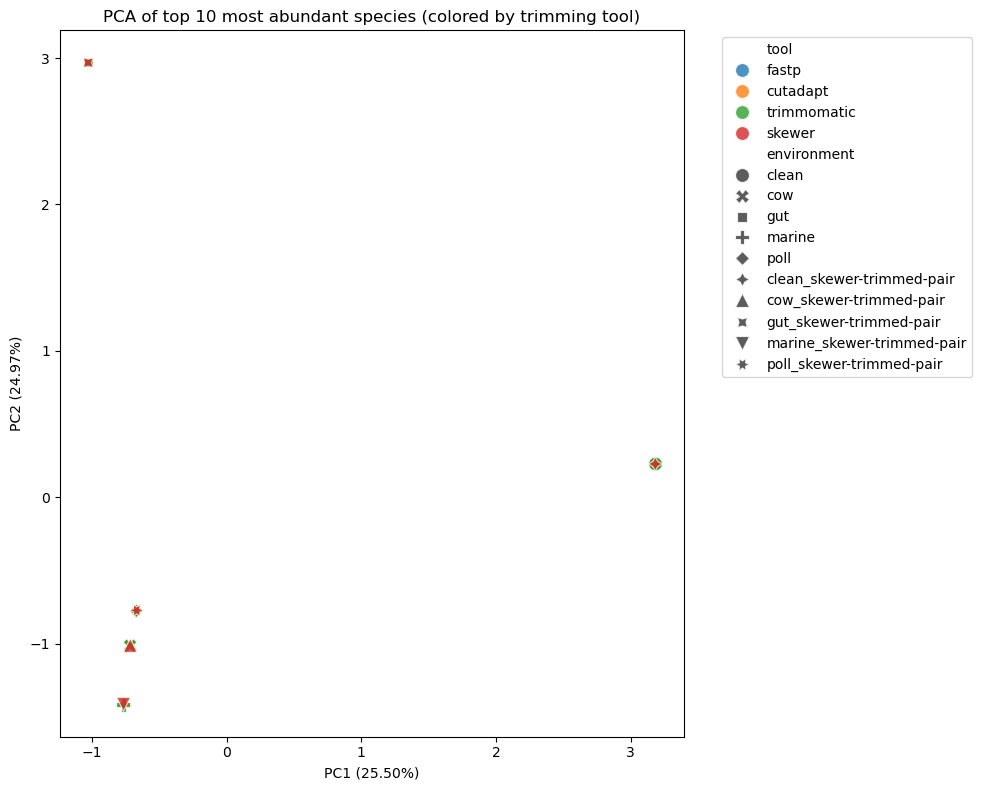

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
#plot pca with labelling , saving pca as png
plt.figure(figsize=(10, 8))
sns.scatterplot(data=scores_df, x='PC1', y='PC2', hue='tool', style='environment', s=100, alpha=0.8)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('PCA of top 10 most abundant species (colored by trimming tool)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('pca_top10_by_tool.png')